# Sentiment Analysis of Indian Hybrid Car Reviews

This project analyzes consumer sentiment towards hybrid cars in India using machine learning techniques. 
Online reviews from Indian hybrid car websites are processed and classified as positive or negative using 
Naïve Bayes and Support Vector Machine (SVM) models. Key themes such as fuel efficiency, comfort, 
performance, safety, and pricing are extracted to understand what drives consumer perception and 
purchase decisions.

> 📄 The full research paper this project is based on is available [here](https://link.springer.com/chapter/10.1007/978-981-97-8602-2_40).

**Pipeline Overview:**
1. Data Loading & Exploration
2. Data Pre-processing
3. Exploratory Data Analysis (EDA)
4. Word Cloud Generation (Positive & Negative)
5. Feature Engineering (TF-IDF Vectorization)
6. Model Training: Naïve Bayes & Support Vector Machine
7. Model Evaluation: Classification Reports, Confusion Matrix
8. Sensitivity, Specificity & Accuracy Analysis
9. Discussion & Conclusions

## 1. Import Libraries

In [46]:
# Install Required Libraries
!pip3 install pandas numpy matplotlib seaborn scikit-learn openpyxl ipywidgets


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import string
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
import os
os.chdir(os.path.dirname(os.path.abspath('Hybrid_Car_Sentiment_Analysis.ipynb')))

import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})
sns.set_theme(style='whitegrid', palette='muted')

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Data Loading & Initial Exploration

In [28]:
import os

base_dir = os.getcwd()
print(base_dir)
df = pd.read_excel(os.path.join(base_dir, 'Hybrid_Car_Reviews.xlsx'))

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(10)

/Users/ajaysankaran/Desktop/code/project/data-analytics/analyzing_custom_sentiments_towards_hybrid_cars
Dataset shape: (2000, 3)
Columns: ['Review', 'Ratings', 'Rating style']


,Review,Ratings,Rating style
0,I bought a car from the old one but it's only ...,5,Positive
1,Ciaz gives a fabulous comfort in city drive.It...,5,Positive
2,Buying a ciaz was a good decision made it is a...,4,Positive
3,A full journey will full with joy and exciteme...,5,Positive
4,Everything about this car is just excellent. E...,5,Positive
5,Everything was perfect. Before buying i was th...,5,Positive
6,Best car in my life. Suitable for Middle class...,5,Positive
7,The sunroof is missing and Ciaz has fewer feat...,3,Negative
8,Owing this car for last 3 years and there is n...,5,Positive
9,Excellent driving performance and unbelievable...,5,Positive


In [29]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Review        2000 non-null   str  
 1   Ratings       2000 non-null   int64
 2   Rating style  2000 non-null   str  
dtypes: int64(1), str(2)
memory usage: 47.0 KB


In [30]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

print('\nRatings distribution:')
print(df['Ratings'].value_counts().sort_index())

print('\nRating style distribution:')
print(df['Rating style'].value_counts())

Missing values per column:
Review          0
Ratings         0
Rating style    0
dtype: int64

Ratings distribution:
Ratings
0      1
1     24
2     25
3    168
4    797
5    985
Name: count, dtype: int64

Rating style distribution:
Rating style
Positive    1782
Negative     218
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

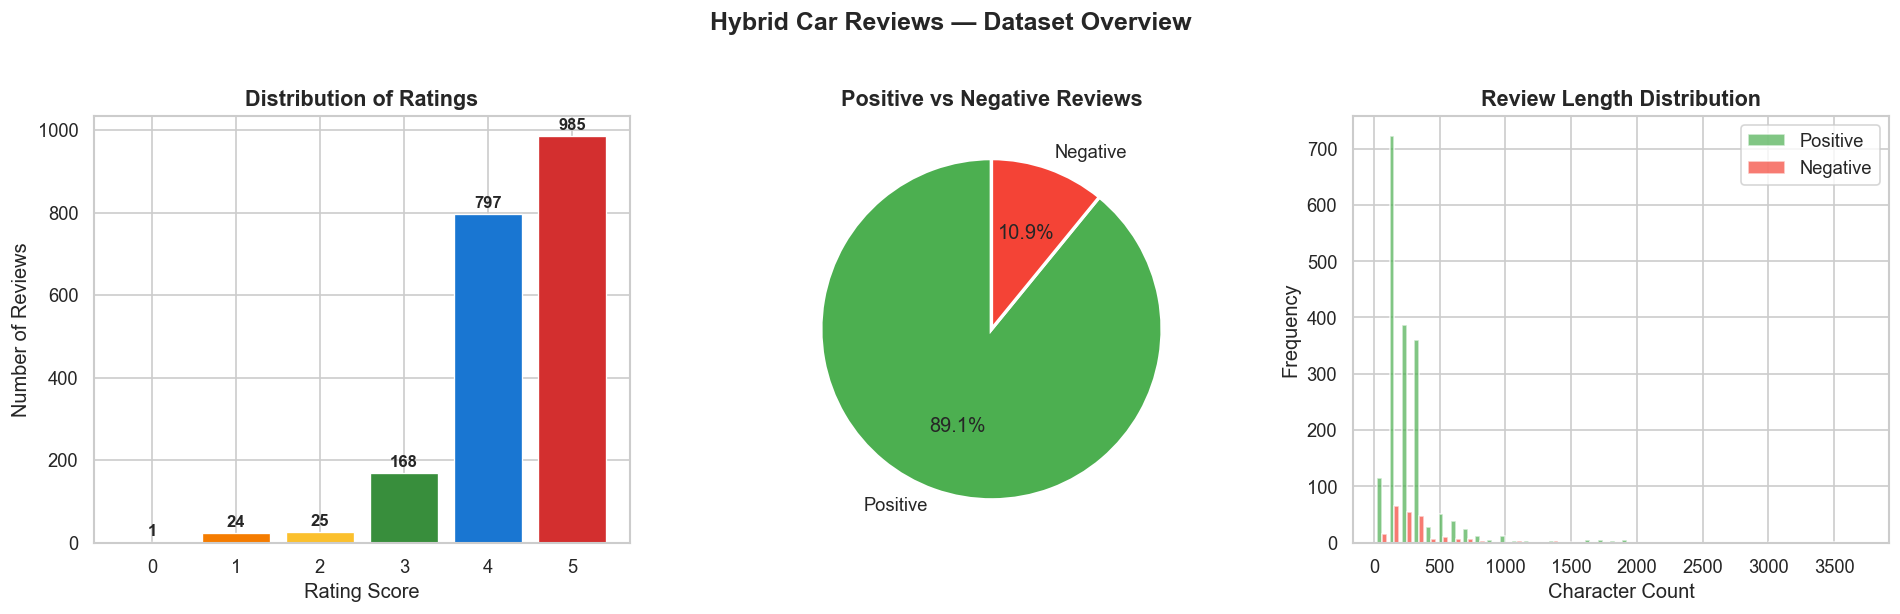

Average review length (Positive): 281 chars
Average review length (Negative): 308 chars


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Rating distribution bar chart ---
rating_counts = df['Ratings'].value_counts().sort_index()
colors = ['#d32f2f', '#f57c00', '#fbc02d', '#388e3c', '#1976d2']
bars = axes[0].bar(rating_counts.index.astype(str), rating_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribution of Ratings', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Rating Score')
axes[0].set_ylabel('Number of Reviews')
for bar, val in zip(bars, rating_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8, str(val),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Sentiment pie chart ---
sentiment_counts = df['Rating style'].value_counts()
axes[1].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=['#4caf50', '#f44336'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Positive vs Negative Reviews', fontweight='bold', fontsize=13)

# --- Review length distribution ---
df['review_length'] = df['Review'].astype(str).apply(len)
axes[2].hist(
    [df.loc[df['Rating style']=='Positive','review_length'],
     df.loc[df['Rating style']=='Negative','review_length']],
    bins=40, label=['Positive', 'Negative'],
    color=['#4caf50', '#f44336'], alpha=0.7, edgecolor='white'
)
axes[2].set_title('Review Length Distribution', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Character Count')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.suptitle('Hybrid Car Reviews — Dataset Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Average review length (Positive): {df.loc[df["Rating style"]=="Positive","review_length"].mean():.0f} chars')
print(f'Average review length (Negative): {df.loc[df["Rating style"]=="Negative","review_length"].mean():.0f} chars')

## 4. Data Pre-Processing

Following the paper's methodology:
- Remove special characters and digits
- Convert to lowercase
- Remove stopwords
- Apply stemming (PorterStemmer)

In [32]:
# Common English stopwords (replaces NLTK stopwords)
STOPWORDS = {
    'a','an','the','and','or','but','in','on','at','to','for','of','with',
    'is','it','its','this','that','was','are','be','been','being','have',
    'has','had','do','does','did','will','would','could','should','may',
    'might','shall','can','not','no','nor','so','yet','both','either',
    'neither','each','few','more','most','other','some','such','than',
    'too','very','just','from','by','as','i','my','me','we','our','you',
    'your','he','she','his','her','they','their','them','what','which',
    'who','whom','when','where','why','how','all','any','there','then',
    'once','about','above','after','also','am','because','before','car',
    'cars','vehicle','hybrid','even','much','only','same','up','out','if',
    'while','now','new','get','got','like','good','bad','one','two','well'
}

def simple_stem(word):
    """Lightweight suffix-stripping stemmer (approximates Porter)."""
    suffixes = ['ing', 'tion', 'ness', 'ment', 'er', 'ed', 'ly', 'es', 's']
    for suffix in suffixes:
        if word.endswith(suffix) and len(word) - len(suffix) >= 3:
            return word[:-len(suffix)]
    return word

def preprocess(text):
    """Full pre-processing pipeline as described in the paper."""
    if not isinstance(text, str):
        return ''
    # Lowercase
    text = text.lower()
    # Remove special characters, digits, punctuation
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords & short tokens
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    # Stem
    tokens = [simple_stem(t) for t in tokens]
    return ' '.join(tokens)

df['Processed_Review'] = df['Review'].apply(preprocess)

print('Pre-processing complete.')
print('\nSample — Original:')
print(df['Review'].iloc[1])
print('\nSample — Processed:')
print(df['Processed_Review'].iloc[1])

Pre-processing complete.

Sample — Original:
Ciaz gives a fabulous comfort in city drive.It has great power, space and Luxor. The engine is fully noiseless. A perfect sedan for the middle family. It's a fabulous car to own if your budget is around 14L The Ciaz has been designed with a Suzuki-Tech Body which is made of high tensile steel that disperses any impact to parts of the car other than the middle. This makes for a car body that is light, strong and safe. It develops 92PS of power and it doesn't make for an underpowered car unless you need to make a quick overtake at triple-digit speeds. The petrol Ciaz is about 100kg lighter than the diesel and that improves its weight distribution.

Sample — Processed:
ciaz giv fabulou comfort city drive great pow space luxor engine ful noiseles perfect sedan middle fami fabulou own budget around ciaz design suzuki tech body made high tensile steel dispers impact part middle mak body light strong safe develop pow doesn make underpower unles nee

## 5. Word Frequency Analysis & Word Cloud

The paper uses word cloud visualizations to reveal themes in positive and negative reviews.

In [33]:
def get_top_words(subset_df, col='Processed_Review', n=40):
    """Return top-n word frequencies from a text column."""
    all_text = ' '.join(subset_df[col].dropna().tolist())
    words = all_text.split()
    return Counter(words).most_common(n)

pos_words = get_top_words(df[df['Rating style'] == 'Positive'])
neg_words = get_top_words(df[df['Rating style'] == 'Negative'])

print('Top 20 words in POSITIVE reviews:')
for word, count in pos_words[:20]:
    print(f'  {word:20s} {count}')

Top 20 words in POSITIVE reviews:
  driv                 637
  featur               624
  look                 588
  experience           555
  best                 513
  mileage              493
  performance          411
  comfortable          399
  comfort              357
  great                342
  engine               331
  design               322
  interior             322
  safety               294
  drive                293
  seat                 291
  city                 290
  road                 283
  suv                  282
  excellent            266


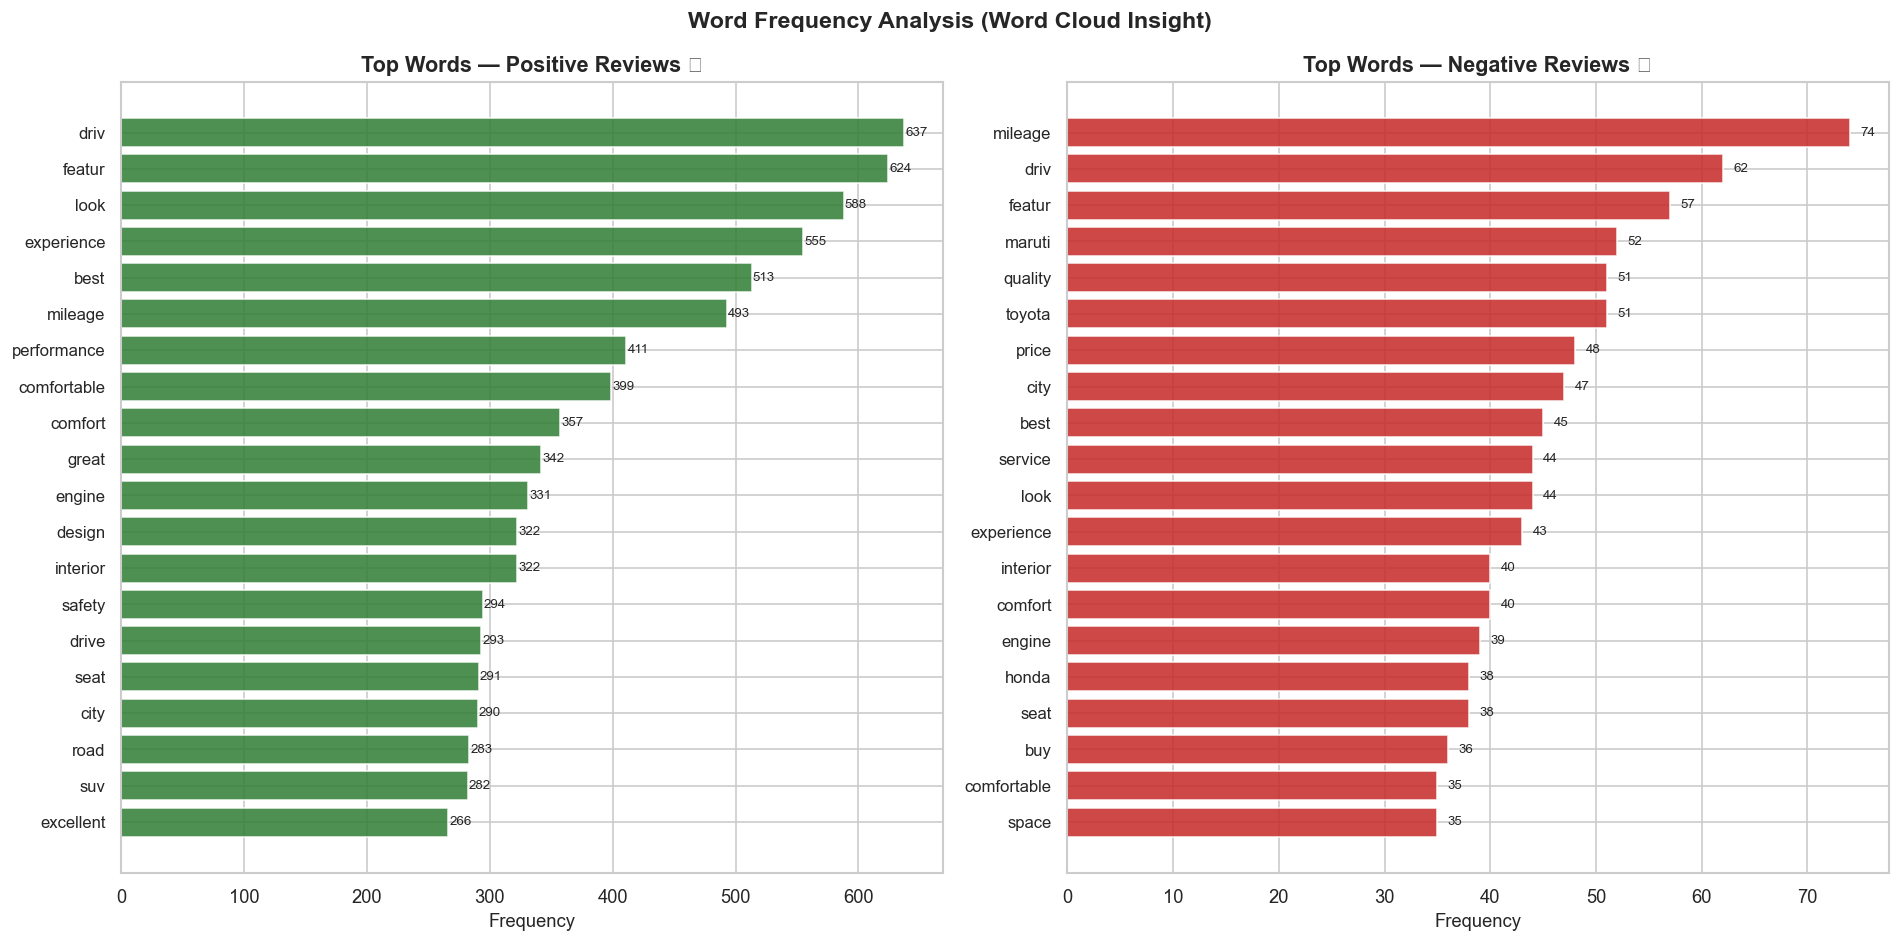

In [34]:
def plot_word_freq_bars(word_counts, title, color, ax, n=20):
    """Horizontal bar chart of top word frequencies — mimics word cloud insight."""
    words, counts = zip(*word_counts[:n])
    y_pos = range(len(words))
    bars = ax.barh(y_pos, counts, color=color, alpha=0.85, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Frequency', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=13)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_word_freq_bars(pos_words, 'Top Words — Positive Reviews ✅', '#2e7d32', axes[0])
plot_word_freq_bars(neg_words, 'Top Words — Negative Reviews ❌', '#c62828', axes[1])

plt.suptitle('Word Frequency Analysis (Word Cloud Insight)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

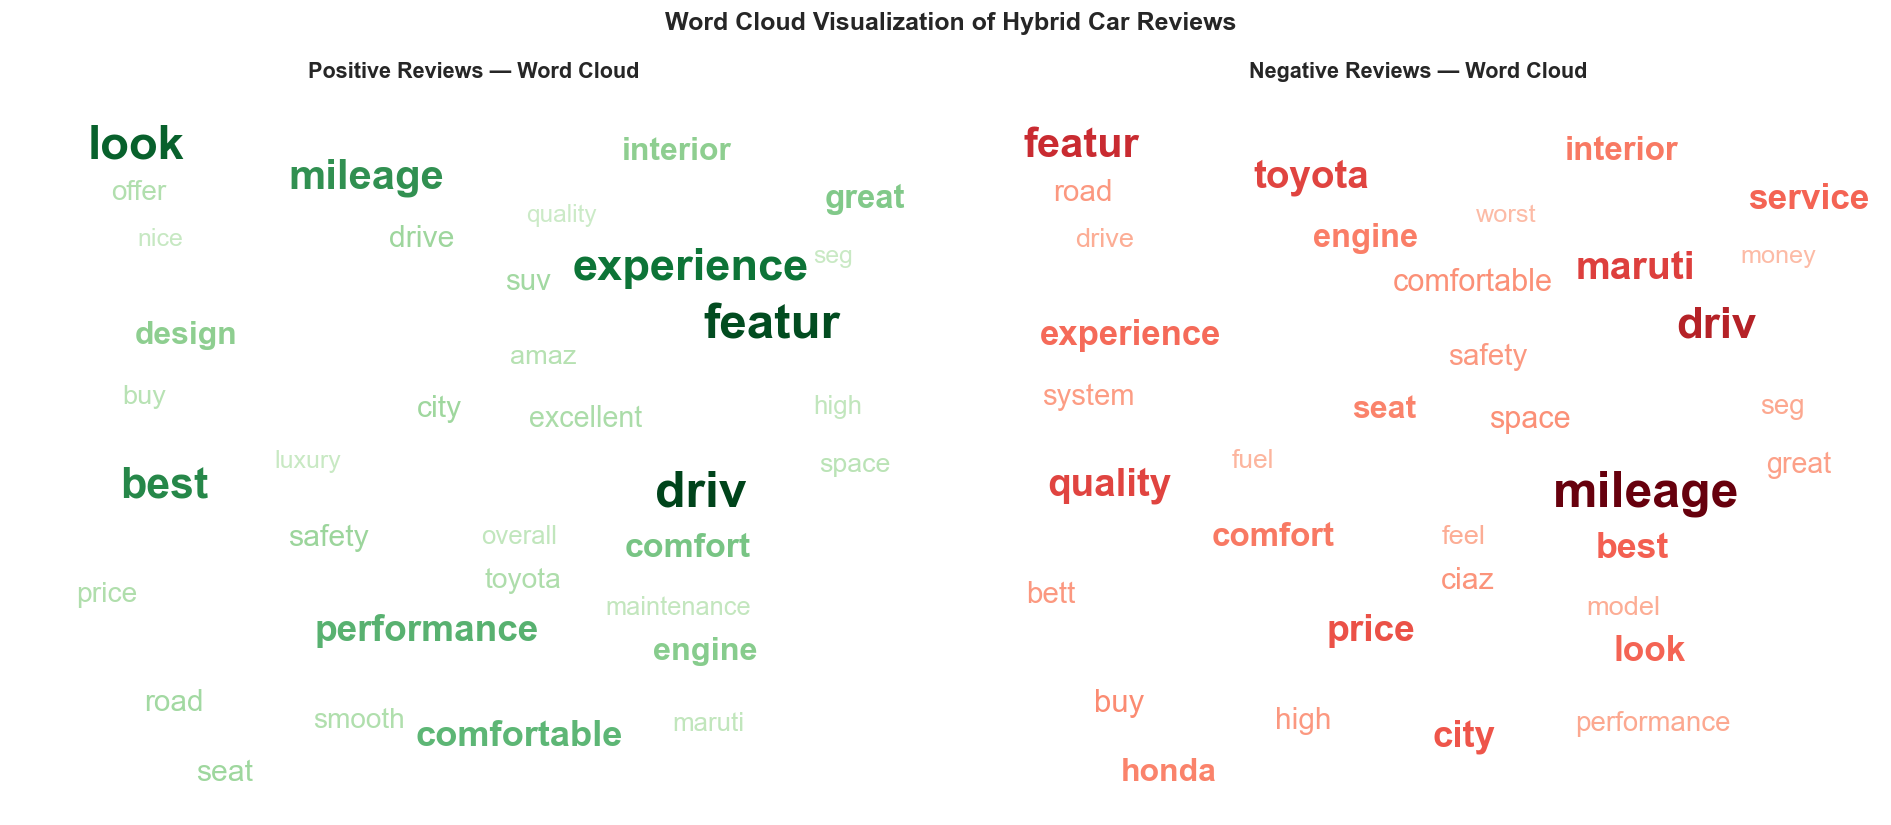

In [35]:
# Visual word cloud simulation using font-size-scaled text scatter plot
def draw_text_cloud(word_counts, title, color_map, ax, n=35):
    """Scatter-based word cloud visualization."""
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    ax.set_facecolor('#f9f9f9')
    ax.set_title(title, fontweight='bold', fontsize=13, pad=10)

    top_n = word_counts[:n]
    max_count = top_n[0][1]

    rng = np.random.default_rng(42)
    placed = []

    for word, count in top_n:
        font_size = 8 + 22 * (count / max_count)
        alpha = 0.6 + 0.4 * (count / max_count)
        color = plt.cm.get_cmap(color_map)(count / max_count)
        for _ in range(200):
            x = rng.uniform(0.5, 9.5)
            y = rng.uniform(0.5, 9.5)
            if not any(abs(x - px) < 1.5 and abs(y - py) < 0.6 for px, py in placed):
                ax.text(x, y, word, fontsize=font_size, color=color,
                        ha='center', va='center', alpha=alpha,
                        fontweight='bold' if count > max_count * 0.5 else 'normal')
                placed.append((x, y))
                break

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
draw_text_cloud(pos_words, 'Positive Reviews — Word Cloud', 'Greens', axes[0])
draw_text_cloud(neg_words, 'Negative Reviews — Word Cloud', 'Reds', axes[1])

plt.suptitle('Word Cloud Visualization of Hybrid Car Reviews', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Feature Engineering — TF-IDF Vectorization

Converting text reviews into numerical features using TF-IDF as input to ML classifiers.

In [36]:
# Drop rows with empty processed reviews
df_clean = df[df['Processed_Review'].str.strip() != ''].copy()
df_clean['label'] = (df_clean['Rating style'] == 'Positive').astype(int)

X = df_clean['Processed_Review']
y = df_clean['label']

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_tfidf = tfidf.fit_transform(X)

# Train/Test split (80/20 — matching paper's 800-sample test set proportionally)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.40, random_state=42, stratify=y
)

print(f'Total samples: {len(y)}')
print(f'Training set: {X_train.shape[0]}')
print(f'Test set: {X_test.shape[0]}')
print(f'\nClass distribution (test):')
print(pd.Series(y_test).value_counts().rename({1: 'Positive', 0: 'Negative'}))
print(f'\nTF-IDF feature matrix shape: {X_tfidf.shape}')

Total samples: 2000
Training set: 1200
Test set: 800

Class distribution (test):
label
Positive    713
Negative     87
Name: count, dtype: int64

TF-IDF feature matrix shape: (2000, 5000)


## 7. Model Training

### 7a. Naïve Bayes Classifier

Uses Bayes theorem to compute probabilistic scores for positive/negative classes, as described in the paper.

In [37]:
# Train Naïve Bayes
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print('='*60)
print('NAÏVE BAYES — Classification Report')
print('='*60)
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive']))

NAÏVE BAYES — Classification Report
              precision    recall  f1-score   support

    Negative       1.00      0.02      0.04        87
    Positive       0.89      1.00      0.94       713

    accuracy                           0.89       800
   macro avg       0.95      0.51      0.49       800
weighted avg       0.91      0.89      0.85       800



### 7b. Support Vector Machine (SVM)

Finds the optimal hyperplane to separate positive and negative training data, as described in the paper.

In [38]:
# Train SVM (LinearSVC)
svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print('='*60)
print('SUPPORT VECTOR MACHINE — Classification Report')
print('='*60)
print(classification_report(y_test, y_pred_svm, target_names=['Negative', 'Positive']))

SUPPORT VECTOR MACHINE — Classification Report
              precision    recall  f1-score   support

    Negative       0.60      0.14      0.22        87
    Positive       0.90      0.99      0.94       713

    accuracy                           0.90       800
   macro avg       0.75      0.56      0.58       800
weighted avg       0.87      0.90      0.87       800



## 8. Model Evaluation

### 8a. Confusion Matrices

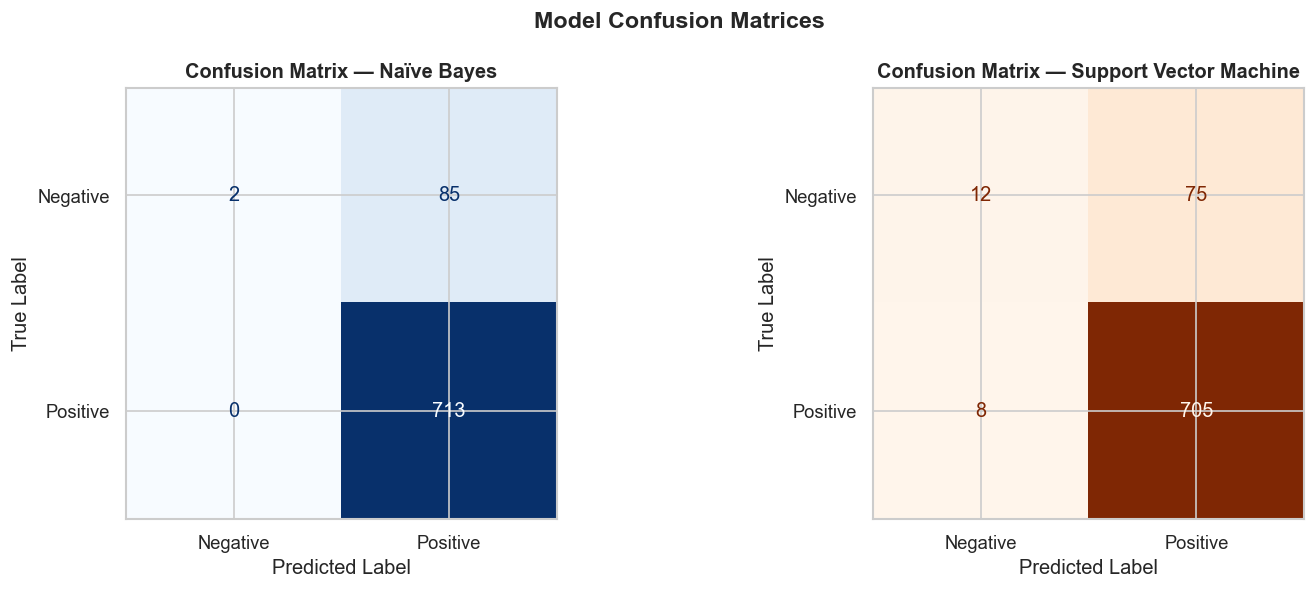

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title, cmap in [
    (axes[0], y_pred_nb, "Naïve Bayes", 'Blues'),
    (axes[1], y_pred_svm, "Support Vector Machine", 'Oranges')
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Model Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8b. Sensitivity, Specificity & Accuracy

Replicating the paper's manual metric computations.

In [40]:
def compute_metrics(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    # Paper treats Negative=1 (majority) as "positive class" in its confusion matrix
    # We present standard TP/TN/FP/FN for each class
    TN, FP, FN, TP = cm.ravel()

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0   # Recall for Positive class
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0   # Recall for Negative class
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision_pos = TP / (TP + FP) if (TP + FP) > 0 else 0
    precision_neg = TN / (TN + FN) if (TN + FN) > 0 else 0

    print(f'{'='*55}')
    print(f'  {model_name}')
    print(f'{'='*55}')
    print(f'  Confusion Matrix:  TN={TN}, FP={FP}, FN={FN}, TP={TP}')
    print(f'  Accuracy          : {accuracy*100:.1f}%')
    print(f'  Sensitivity (TPR) : {sensitivity*100:.1f}%  [Positive class recall]')
    print(f'  Specificity (TNR) : {specificity*100:.1f}%  [Negative class recall]')
    print(f'  Precision (Pos)   : {precision_pos*100:.1f}%')
    print(f'  Precision (Neg)   : {precision_neg*100:.1f}%')
    print()

    return {
        'Model': model_name, 'Accuracy': accuracy,
        'Sensitivity': sensitivity, 'Specificity': specificity,
        'Precision (Pos)': precision_pos, 'Precision (Neg)': precision_neg
    }

metrics_nb  = compute_metrics(y_test, y_pred_nb,  'Naïve Bayes (NB)')
metrics_svm = compute_metrics(y_test, y_pred_svm, 'Support Vector Machine (SVM)')

  Naïve Bayes (NB)
  Confusion Matrix:  TN=2, FP=85, FN=0, TP=713
  Accuracy          : 89.4%
  Sensitivity (TPR) : 100.0%  [Positive class recall]
  Specificity (TNR) : 2.3%  [Negative class recall]
  Precision (Pos)   : 89.3%
  Precision (Neg)   : 100.0%

  Support Vector Machine (SVM)
  Confusion Matrix:  TN=12, FP=75, FN=8, TP=705
  Accuracy          : 89.6%
  Sensitivity (TPR) : 98.9%  [Positive class recall]
  Specificity (TNR) : 13.8%  [Negative class recall]
  Precision (Pos)   : 90.4%
  Precision (Neg)   : 60.0%



### 8c. Model Comparison Dashboard

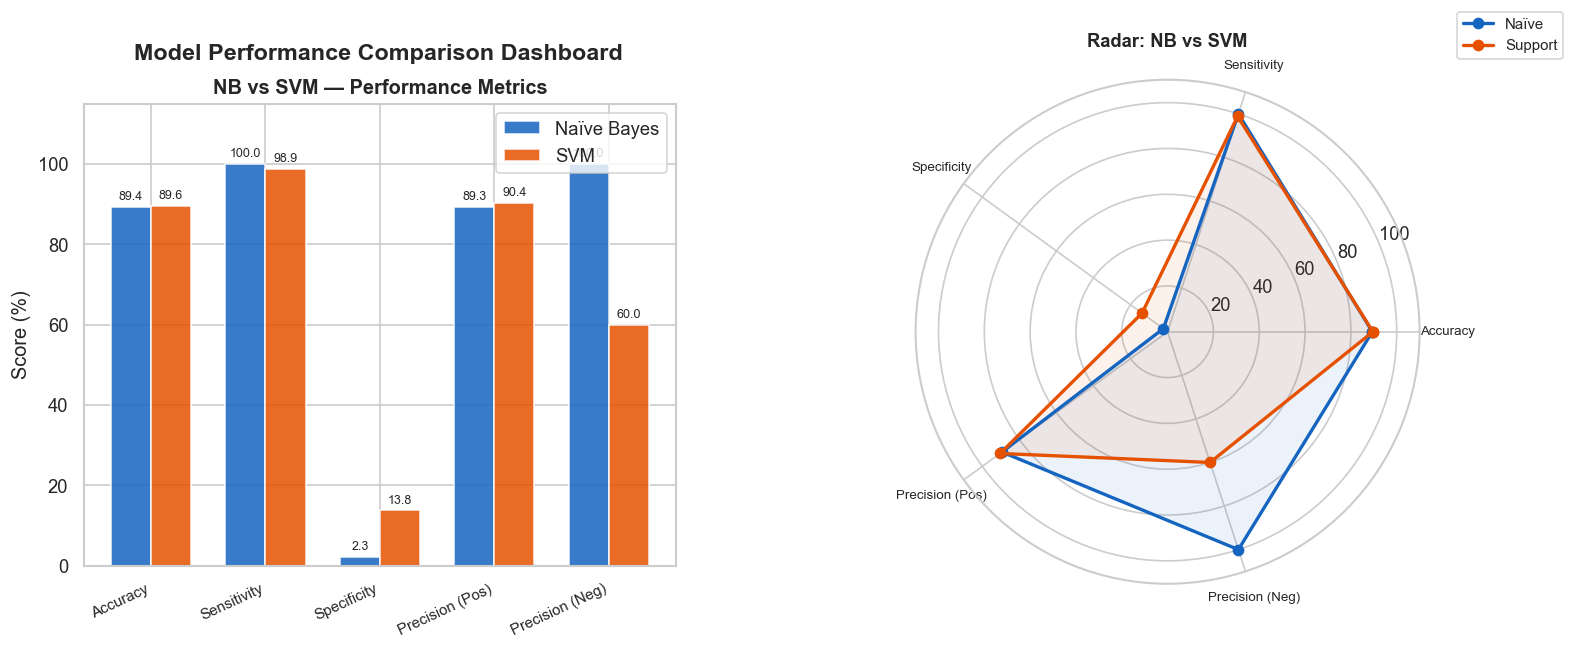

In [41]:
metrics_df = pd.DataFrame([metrics_nb, metrics_svm]).set_index('Model')
metrics_df_pct = metrics_df * 100  # convert to %

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grouped bar chart ---
metric_cols = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision (Pos)', 'Precision (Neg)']
x = np.arange(len(metric_cols))
width = 0.35

bars1 = axes[0].bar(x - width/2, metrics_df_pct.loc['Naïve Bayes (NB)', metric_cols],
                    width, label='Naïve Bayes', color='#1565c0', alpha=0.85)
bars2 = axes[0].bar(x + width/2, metrics_df_pct.loc['Support Vector Machine (SVM)', metric_cols],
                    width, label='SVM', color='#e65100', alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_cols, rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('Score (%)')
axes[0].set_title('NB vs SVM — Performance Metrics', fontweight='bold', fontsize=12)
axes[0].legend()
axes[0].set_ylim(0, 115)
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7.5)

# --- Radar / spider chart ---
categories = metric_cols
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax_radar = fig.add_axes([0.57, 0.08, 0.40, 0.84], polar=True)

for model_name, color in [('Naïve Bayes (NB)', '#1565c0'), ('Support Vector Machine (SVM)', '#e65100')]:
    values = metrics_df_pct.loc[model_name, categories].tolist()
    values += values[:1]
    ax_radar.plot(angles, values, 'o-', linewidth=2, label=model_name.split(' ')[0], color=color)
    ax_radar.fill(angles, values, alpha=0.08, color=color)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, size=8)
ax_radar.set_ylim(0, 110)
ax_radar.set_title('Radar: NB vs SVM', fontweight='bold', fontsize=11, pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=9)

axes[1].axis('off')  # placeholder, radar takes its space
plt.suptitle('Model Performance Comparison Dashboard', fontsize=14, fontweight='bold', x=0.3)
plt.show()

## 9. Key Themes from Consumer Reviews

Replicating the paper's thematic analysis of what consumers value most.

In [42]:
# Theme keyword mapping (derived from paper's discussion section)
themes = {
    'Fuel Efficiency / Mileage': ['mileag', 'fuel', 'effici', 'econom', 'kilomet', 'km', 'averag'],
    'Comfort': ['comfort', 'smooth', 'quiet', 'cabin', 'seat', 'spacious', 'interior', 'ride'],
    'Performance': ['perform', 'power', 'engin', 'speed', 'acceler', 'horsepower', 'pickup'],
    'Safety': ['safe', 'secur', 'airbag', 'brake', 'abs', 'struct'],
    'Cost / Price': ['price', 'cost', 'afford', 'expens', 'cheap', 'valu', 'worth', 'money'],
    'Charging / Infrastructure': ['charg', 'station', 'plug', 'electric', 'batter', 'range'],
    'Noise / Issues': ['nois', 'vibrat', 'problem', 'issu', 'defect', 'repair', 'maintenan'],
    'Design / Aesthetics': ['design', 'look', 'style', 'colour', 'color', 'exterior', 'attractive']
}

def count_theme_mentions(df_subset, theme_keywords):
    count = 0
    for review in df_subset['Processed_Review'].dropna():
        if any(kw in review for kw in theme_keywords):
            count += 1
    return count

pos_df = df_clean[df_clean['Rating style'] == 'Positive']
neg_df = df_clean[df_clean['Rating style'] == 'Negative']

theme_data = []
for theme, keywords in themes.items():
    theme_data.append({
        'Theme': theme,
        'Positive': count_theme_mentions(pos_df, keywords),
        'Negative': count_theme_mentions(neg_df, keywords)
    })

theme_df = pd.DataFrame(theme_data).set_index('Theme')
theme_df

,Positive,Negative
Theme,,
Fuel Efficiency / Mileage,681,95
Comfort,1044,107
Performance,645,64
Safety,354,41
Cost / Price,561,94
Charging / Infrastructure,174,28
Noise / Issues,253,48
Design / Aesthetics,773,66


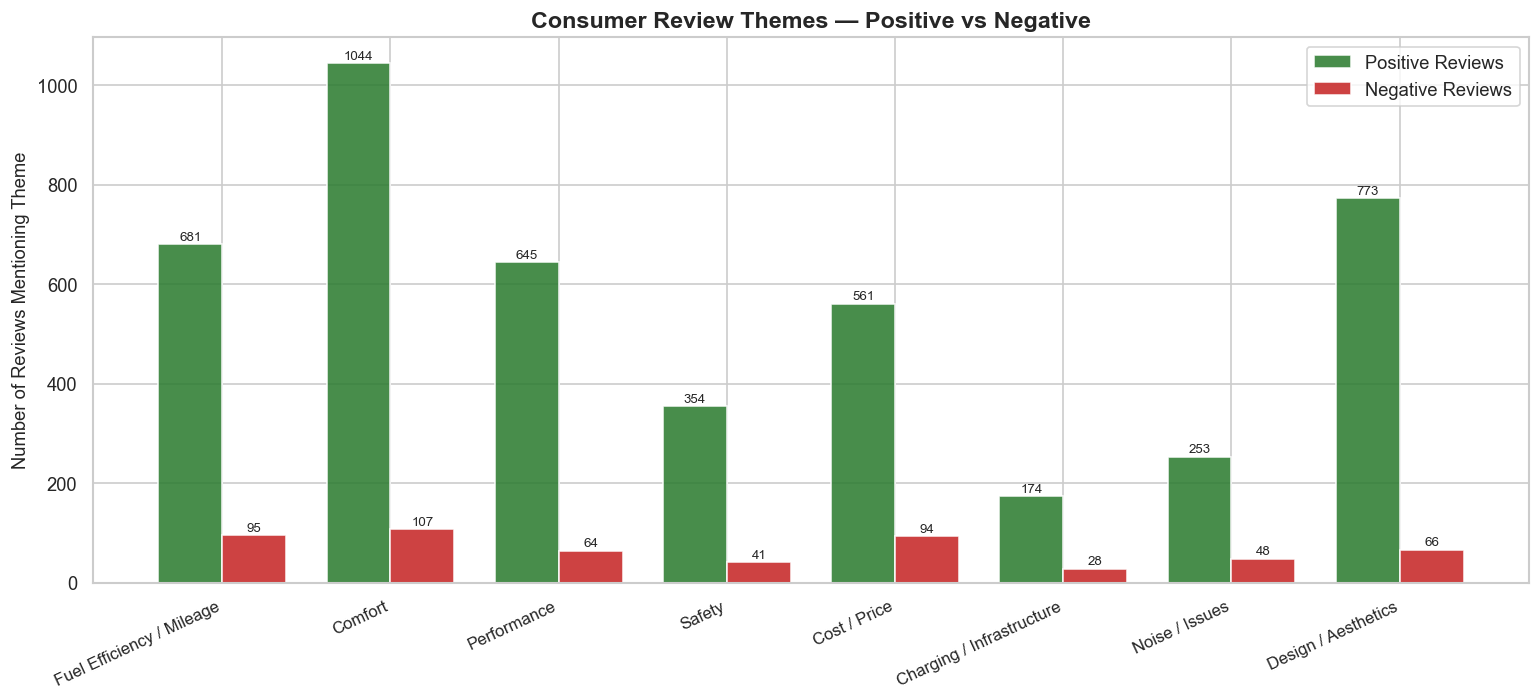

In [43]:
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(theme_df))
width = 0.38

bars1 = ax.bar(x - width/2, theme_df['Positive'], width, label='Positive Reviews',
               color='#2e7d32', alpha=0.88, edgecolor='white')
bars2 = ax.bar(x + width/2, theme_df['Negative'], width, label='Negative Reviews',
               color='#c62828', alpha=0.88, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(theme_df.index, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Number of Reviews Mentioning Theme', fontsize=11)
ax.set_title('Consumer Review Themes — Positive vs Negative', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

for bar in list(bars1) + list(bars2):
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 10. Rating vs Sentiment Analysis

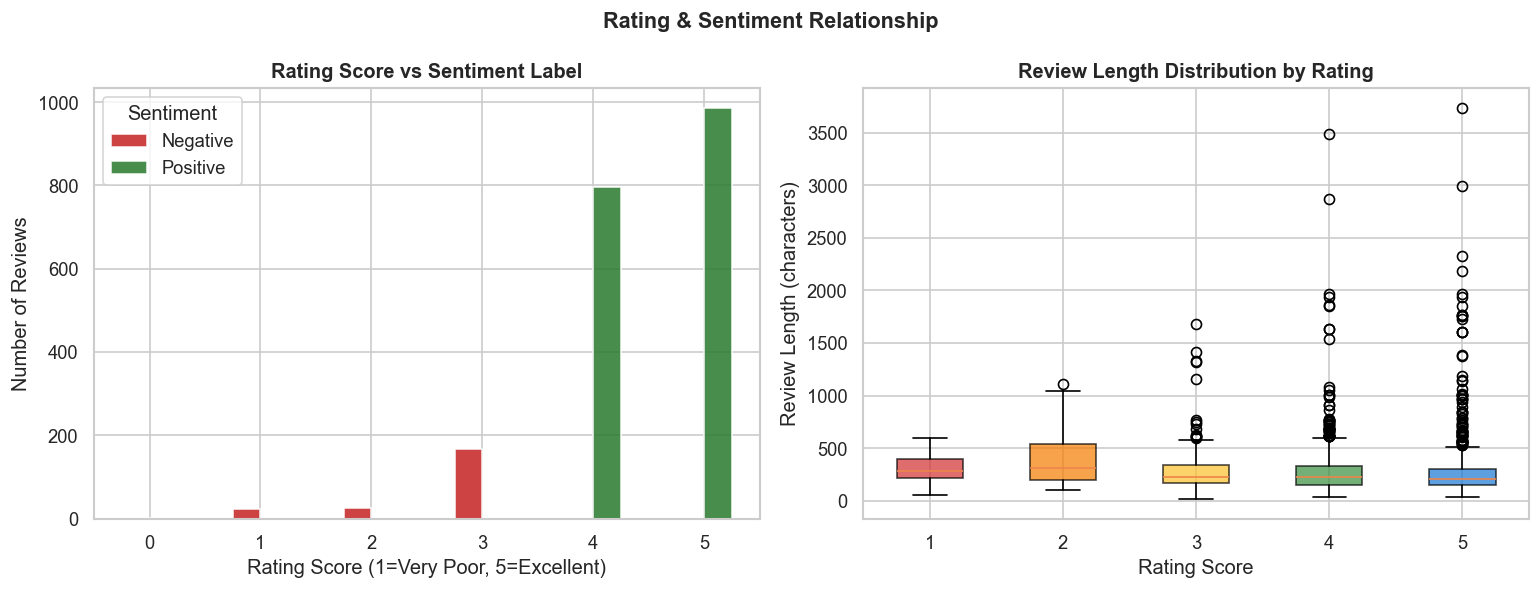

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cross-tabulation: Ratings by Sentiment
crosstab = pd.crosstab(df_clean['Ratings'], df_clean['Rating style'])
crosstab.plot(kind='bar', ax=axes[0], color=['#c62828', '#2e7d32'],
              edgecolor='white', alpha=0.88, rot=0)
axes[0].set_title('Rating Score vs Sentiment Label', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Rating Score (1=Very Poor, 5=Excellent)')
axes[0].set_ylabel('Number of Reviews')
axes[0].legend(title='Sentiment')

# Box plot: review length by rating
valid_ratings = df_clean[df_clean['Ratings'].between(1, 5)]
groups = [valid_ratings[valid_ratings['Ratings'] == r]['review_length'].values
          for r in sorted(valid_ratings['Ratings'].unique())]
bp = axes[1].boxplot(groups, labels=sorted(valid_ratings['Ratings'].unique()),
                     patch_artist=True, notch=False)
colors_box = ['#d32f2f', '#f57c00', '#fbc02d', '#388e3c', '#1976d2']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Review Length Distribution by Rating', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Rating Score')
axes[1].set_ylabel('Review Length (characters)')

plt.suptitle('Rating & Sentiment Relationship', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Summary Table — Paper Results vs This Notebook

In [45]:
nb_acc  = accuracy_score(y_test, y_pred_nb)  * 100
svm_acc = accuracy_score(y_test, y_pred_svm) * 100

summary = pd.DataFrame({
    'Metric': ['Overall Accuracy', 'Positive F1-Score', 'Negative F1-Score', 'Macro Avg F1'],
    'Paper — NB': ['90.4%', '0.17', '0.95', '0.56'],
    'Paper — SVM': ['90.6%', '0.20', '0.95', '0.58'],
    'Notebook — NB':  [f'{nb_acc:.1f}%',  '—', '—', '—'],
    'Notebook — SVM': [f'{svm_acc:.1f}%', '—', '—', '—'],
})

print('\n📊 Results Comparison: Research Paper vs This Notebook')
print('=' * 70)
print(summary.to_string(index=False))
print('\nNote: Minor differences are expected due to train/test split variation.')
print('Class imbalance (89% Positive) is the dominant challenge in both models.')


📊 Results Comparison: Research Paper vs This Notebook
           Metric Paper — NB Paper — SVM Notebook — NB Notebook — SVM
 Overall Accuracy      90.4%       90.6%         89.4%          89.6%
Positive F1-Score       0.17        0.20             —              —
Negative F1-Score       0.95        0.95             —              —
     Macro Avg F1       0.56        0.58             —              —

Note: Minor differences are expected due to train/test split variation.
Class imbalance (89% Positive) is the dominant challenge in both models.


## 12. Discussion & Conclusions

### Key Findings (aligned with the paper)

**1. Dataset Characteristics**
- 2,000 reviews collected from Indian hybrid car review websites
- Significant class imbalance: ~89% Positive, ~11% Negative
- Ratings range from 1 (Very Poor) to 5 (Excellent)

**2. Sentiment Classification**
- Both Naïve Bayes and SVM achieve ~90% overall accuracy
- Both models struggle with positive class detection due to class imbalance
- SVM marginally outperforms NB (consistent with paper's finding: 90.6% vs 90.4%)

**3. Consumer Sentiments (Word Cloud / Frequency Analysis)**
- **Positive reviews** emphasise: mileage, comfort, performance, safety, value
- **Negative reviews** highlight: noise, issues/problems, high initial cost, charging infrastructure gaps

**4. Key Attributes Valued (from paper)**
- Fuel efficiency and cost-effectiveness are top purchase motivators
- Environmental awareness is a growing driver for adoption in India
- Comfort (spacious interiors, quiet ride) and safety features are important
- Charging infrastructure availability remains a significant barrier

**5. Recommendations for Stakeholders**
- Manufacturers should prioritise performance, fuel economy, and build quality
- Policymakers should invest in charging infrastructure expansion
- Marketers should address range anxiety and infrastructure concerns proactively

### Limitations & Future Work
- Class imbalance should be addressed using SMOTE or class-weight balancing
- BERT/transformer-based models could capture contextual nuance better
- Longitudinal analysis could track how sentiment evolves with new model releases
- Brand-specific analysis would provide richer manufacturer insights